# Описание локального синтетического бенчмарка SEB

Ноутбук описывает локальный синтетический SQL-набор: схему данных, состав запросов, edge-case слой, статистику выполнения и покрытие таблиц/колонок.


## 1. Загрузка артефактов

Здесь загружаются исходные артефакты синтетического набора и итоговый отчёт покрытия, рассчитанный на заполненной базе SQLite.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
pd.options.display.float_format = '{:.4f}'.format

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents)
    if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists()
)

DATA_DIR = PROJECT_ROOT / 'data' / 'nl2sql' / 'synthetic_ecommerce'
DATASET_PATH = DATA_DIR / 'dataset_v1.json'
EDGE_PATH = DATA_DIR / 'edge_cases_v1.json'
COVERAGE_PATH = DATA_DIR / 'coverage_summary.json'
DB_PATH = DATA_DIR / 'snapshot.sqlite'

with DATASET_PATH.open('r', encoding='utf-8') as handle:
    dataset = json.load(handle)
with EDGE_PATH.open('r', encoding='utf-8') as handle:
    edge_cases = json.load(handle)
with COVERAGE_PATH.open('r', encoding='utf-8') as handle:
    coverage = json.load(handle)

core_queries_df = pd.DataFrame(dataset['queries'])
edge_queries_df = pd.DataFrame(edge_cases['queries'])
query_results_df = pd.DataFrame(coverage['query_results'])
row_counts_df = pd.DataFrame([
    {'table': key, 'rows': value} for key, value in coverage['row_counts'].items()
])
column_usage_df = pd.DataFrame([
    {'column': key, 'usage_count': value} for key, value in coverage['column_usage'].items()
]).sort_values(['usage_count', 'column'], ascending=[False, True])
null_ratio_df = pd.DataFrame([
    {'column': key, 'null_ratio': value}
    for key, value in coverage['data_quality_summary']['null_ratio_by_column'].items()
]).sort_values(['null_ratio', 'column'], ascending=[False, True])


## 2. Состав набора

локальный синтетический бенчмарк SEB состоит из базового ядра из 30 SQL-запросов и отдельного слоя edge-case сценариев. Ядро сохраняет распределение 10 / 10 / 10 по уровням сложности, а edge-case запросы рассматриваются отдельно.


In [2]:
summary_df = pd.DataFrame(
    [
        {'metric': 'Core queries', 'value': coverage['query_counts']['core']},
        {'metric': 'Edge-case queries', 'value': coverage['query_counts']['edge_case']},
        {'metric': 'Total queries', 'value': coverage['query_counts']['total']},
        {'metric': 'SQLite snapshot', 'value': DB_PATH.name},
    ]
)

edge_queries_display_df = edge_queries_df[['difficulty', 'group', 'edge_type']].fillna({'edge_type': '—'})

display(summary_df)
display(core_queries_df['difficulty'].value_counts().rename_axis('difficulty').reset_index(name='count'))
display(edge_queries_display_df)


,metric,value
0,Core queries,30
1,Edge-case queries,8
2,Total queries,38
3,SQLite snapshot,snapshot.sqlite


,difficulty,count
0,easy,10
1,medium,10
2,hard,10


,difficulty,group,edge_type
0,edge_case,edge_case,anti_join
1,edge_case,edge_case,anti_join
2,edge_case,edge_case,null_handling
3,edge_case,edge_case,empty_result
4,edge_case,edge_case,null_handling
5,edge_case,edge_case,aggregation_edge
6,edge_case,edge_case,aggregation_edge
7,edge_case,edge_case,empty_result


## 3. Данные и качество заполнения

В разделе фиксируются размеры таблиц и контролируемые особенности синтетических данных: доли `NULL` и нестандартные значения, добавленные для проверки устойчивости SQL-запросов.


In [3]:
display(row_counts_df)
display(null_ratio_df.head(12))
display(pd.DataFrame([
    {'check': key, 'count': value}
    for key, value in coverage['data_quality_summary']['unusual_value_checks'].items()
]))


,table,rows
0,customers,420
1,categories,24
2,products,220
3,orders,720
4,order_items,1440
5,returns,180


,column,null_ratio
23,orders.shipping_state,0.3333
2,categories.parent_category_id,0.2500
36,returns.return_reason,0.1222
10,customers.state,0.1095
28,products.launched_at,0.0682
11,order_items.discount_amount,0.0382
3,customers.city,0.0262
0,categories.category_id,0.0000
1,categories.category_name,0.0000
4,customers.customer_id,0.0000


,check,count
0,products.brand:Brand-X/Legacy,7
1,orders.payment_method:crypto,36
2,returns.return_reason:empty_string,14


## 4. Статистика выполнения SQL

Ниже показаны результаты выполнения эталонных SQL-запросов на заполненной базе: число возвращаемых строк и время выполнения каждого запроса.


,zero_rows_queries,one_row_queries,multi_row_queries,zero_or_one_ratio,is_skewed_to_zero_or_one
0,1,1,36,0.0526,False


,index,group,difficulty,edge_type,rows_returned,execution_time_ms,selectivity
0,1,core,easy,—,46,1.2293,selective
1,2,core,easy,—,5,0.3370,selective
2,3,core,easy,—,36,0.1798,selective
3,4,core,easy,—,42,0.4145,selective
4,5,core,easy,—,10,0.2398,selective
5,6,core,easy,—,6,0.1430,selective
6,7,core,easy,—,47,0.1641,selective
7,8,core,easy,—,10,0.2402,selective
8,9,core,easy,—,379,0.7297,selective
9,10,core,easy,—,30,0.0975,selective


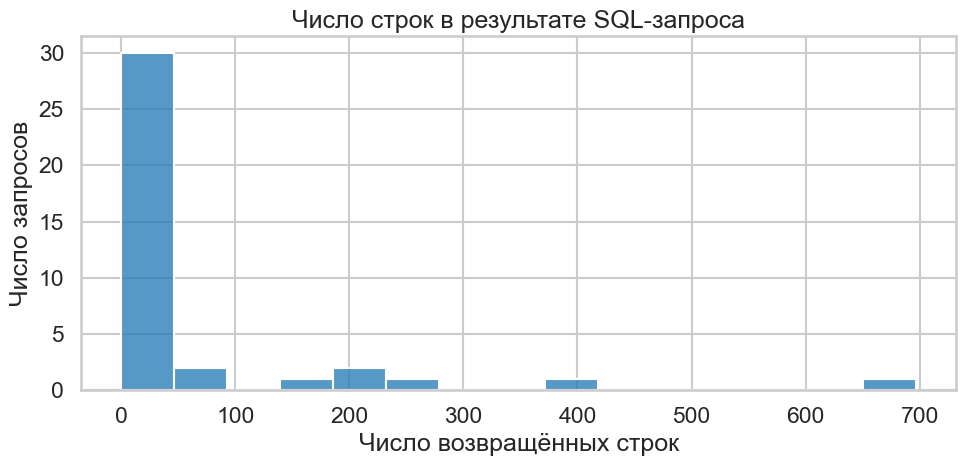

Сохранён файл: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/dataset_description/rows_returned_per_query_ru.png


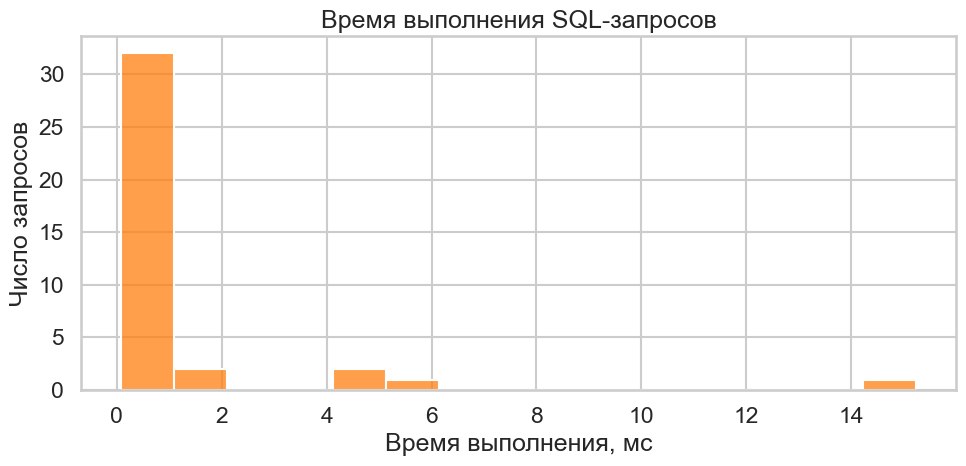

Сохранён файл: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/dataset_description/execution_time_per_query_ru.png


In [4]:
FIGURES_DIR = PROJECT_ROOT / 'results' / 'nl2sql' / 'synthetic_benchmark' / 'figures' / 'dataset_description'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

result_distribution_df = pd.DataFrame([coverage['result_distribution']])
query_results_preview_df = query_results_df[['index', 'group', 'difficulty', 'edge_type', 'rows_returned', 'execution_time_ms', 'selectivity']].copy()
query_results_preview_df['edge_type'] = query_results_preview_df['edge_type'].fillna('—')
display(result_distribution_df)
display(query_results_preview_df.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(query_results_df['rows_returned'], bins=15, ax=ax, color='#1f77b4')
ax.set_title('Число строк в результате SQL-запроса')
ax.set_xlabel('Число возвращённых строк')
ax.set_ylabel('Число запросов')
path = FIGURES_DIR / 'rows_returned_per_query_ru.png'
fig.tight_layout()
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {path}')

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(query_results_df['execution_time_ms'], bins=15, ax=ax, color='#ff7f0e')
ax.set_title('Время выполнения SQL-запросов')
ax.set_xlabel('Время выполнения, мс')
ax.set_ylabel('Число запросов')
path = FIGURES_DIR / 'execution_time_per_query_ru.png'
fig.tight_layout()
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {path}')


## 5. Покрытие схемы и распределения

Этот блок показывает, насколько равномерно используются таблицы и колонки, а также как распределяются пользовательские намерения, селективность и edge-case типы.


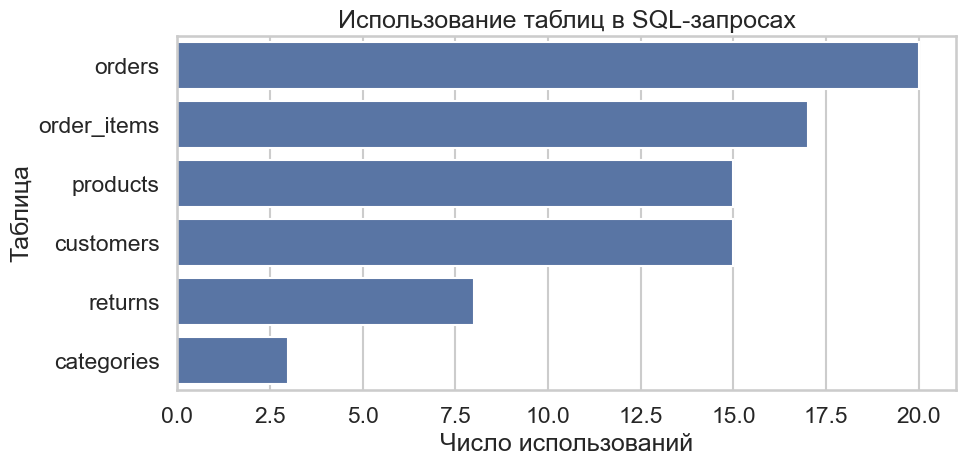

Сохранён файл: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/dataset_description/table_usage_ru.png


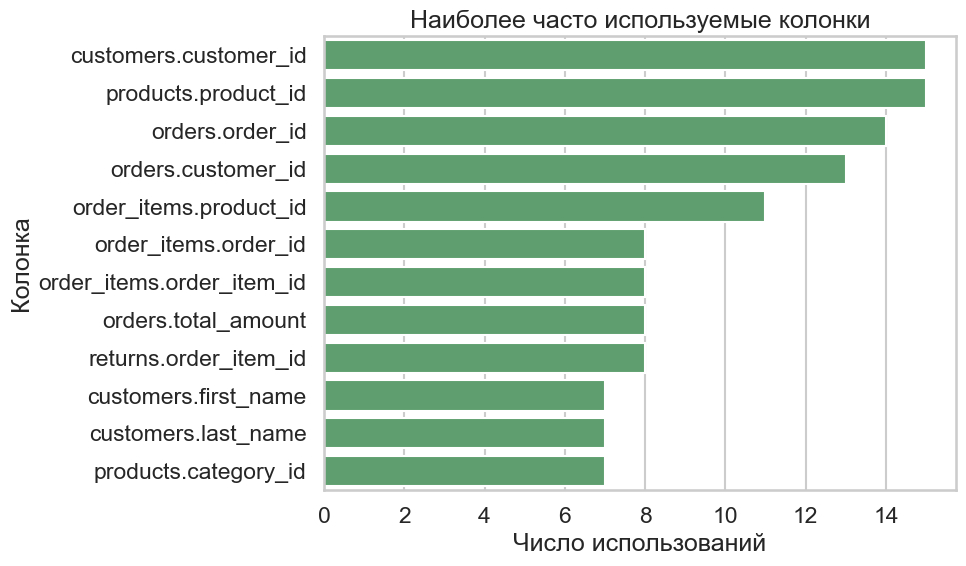

Сохранён файл: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/dataset_description/top_column_usage_ru.png


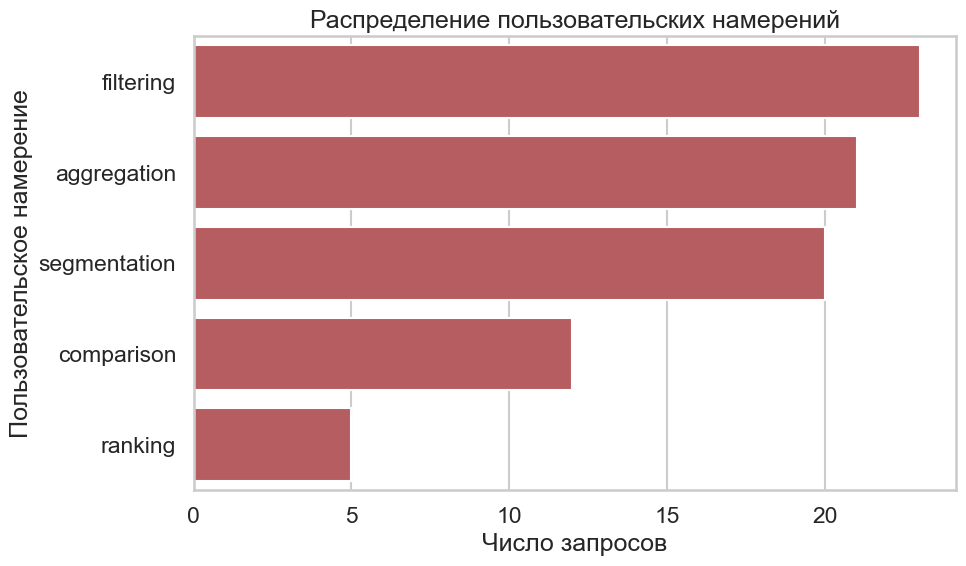

Сохранён файл: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/dataset_description/intent_distribution_ru.png


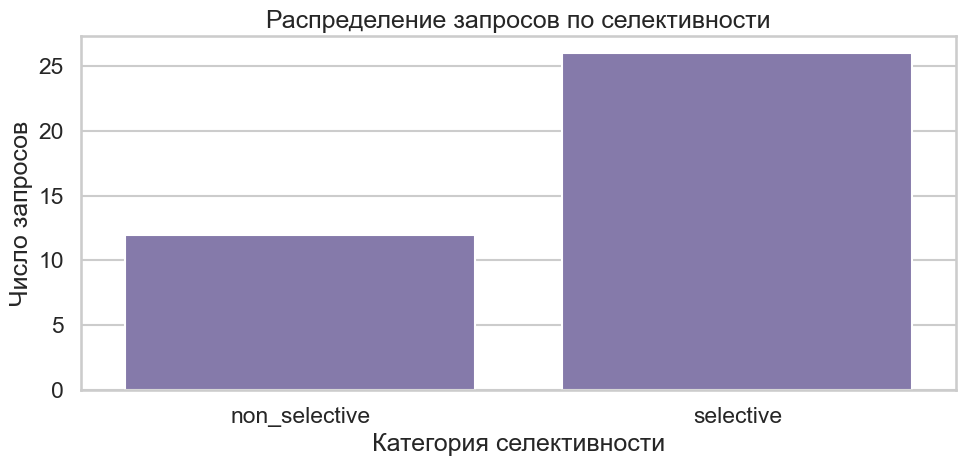

Сохранён файл: /home/count/code/vkr/results/nl2sql/synthetic_benchmark/figures/dataset_description/selectivity_distribution_ru.png


,edge_type,count
0,aggregation_edge,2
1,anti_join,2
2,empty_result,2
3,null_handling,2


,unused_columns


,low_usage_columns
0,categories.parent_category_id
1,customers.city
2,orders.order_date
3,products.is_active
4,products.launched_at
5,returns.return_date


In [5]:
table_usage_df = pd.DataFrame([
    {'table': key, 'usage_count': value}
    for key, value in coverage['table_usage'].items()
]).sort_values('usage_count', ascending=False)
intent_df = pd.DataFrame([
    {'intent': key, 'count': value}
    for key, value in coverage['intent_distribution'].items()
]).sort_values('count', ascending=False)
selectivity_df = pd.DataFrame([
    {'selectivity': key, 'count': value}
    for key, value in coverage['selectivity_distribution'].items()
])
edge_type_df = pd.DataFrame([
    {'edge_type': key, 'count': value}
    for key, value in coverage['edge_type_distribution'].items()
]).sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=table_usage_df, x='usage_count', y='table', ax=ax, color='#4c72b0')
ax.set_title('Использование таблиц в SQL-запросах')
ax.set_xlabel('Число использований')
ax.set_ylabel('Таблица')
path = FIGURES_DIR / 'table_usage_ru.png'
fig.tight_layout()
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {path}')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=column_usage_df.head(12), x='usage_count', y='column', ax=ax, color='#55a868')
ax.set_title('Наиболее часто используемые колонки')
ax.set_xlabel('Число использований')
ax.set_ylabel('Колонка')
path = FIGURES_DIR / 'top_column_usage_ru.png'
fig.tight_layout()
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {path}')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=intent_df, x='count', y='intent', ax=ax, color='#c44e52')
ax.set_title('Распределение пользовательских намерений')
ax.set_xlabel('Число запросов')
ax.set_ylabel('Пользовательское намерение')
path = FIGURES_DIR / 'intent_distribution_ru.png'
fig.tight_layout()
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {path}')

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=selectivity_df, x='selectivity', y='count', ax=ax, color='#8172b2')
ax.set_title('Распределение запросов по селективности')
ax.set_xlabel('Категория селективности')
ax.set_ylabel('Число запросов')
path = FIGURES_DIR / 'selectivity_distribution_ru.png'
fig.tight_layout()
fig.savefig(path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {path}')

display(edge_type_df)
display(pd.DataFrame({'unused_columns': coverage['unused_columns']}))
display(pd.DataFrame({'low_usage_columns': coverage['low_usage_columns']}))


## 6. Краткие выводы

Синтетический набор пригоден для проверки через выполнение SQL: все запросы исполняются на заполненной базе SQLite, результаты не сводятся к тривиальному числу строк, а таблицы и колонки схемы покрываются хотя бы одним запросом. Отчёт покрытия дополнительно фиксирует колонки с низкой частотой использования, что полезно для следующей итерации набора.
